# Mixed model

In [1]:
from pathlib import Path
import sys # for setting the importing env  

project_dir = Path.cwd().parent.parent # Adjust here to get the project_dir

# Add project_dir to sys.path at the first position
if project_dir not in sys.path:
    sys.path.insert(0, str(project_dir))

## Imports

In [23]:
import pandas as pd

from statsmodels.formula.api import logit, ols, mixedlm, glm
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm

from matplotlib import pyplot as plt
import seaborn as sns

In [7]:
from src.utils.data_summary_qc import summarize_columns

## Data

In [24]:
# Load data
data = pd.read_csv(project_dir / 'data/mixed-model-gpt_20260529/demo_longitudinal_biomarker.csv')

print(f"Data shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")

Data shape: (321, 8)
Columns: ['id', 'time', 'diagnosis', 'age', 'sex', 'medication', 'site', 'biomarker']


In [4]:
data.head()

,id,time,diagnosis,age,sex,medication,site,biomarker
0,ID_000,0,NDC,15.863776,Female,No,Site_C,70.382122
1,ID_000,1,NDC,15.863776,Female,No,Site_C,73.741516
2,ID_000,2,NDC,15.863776,Female,No,Site_C,73.784150
3,ID_001,0,NDC,15.576498,Female,No,Site_B,66.998675
4,ID_001,1,NDC,15.576498,Female,No,Site_B,67.313513


In [16]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          321 non-null    str    
 1   time        321 non-null    int64  
 2   diagnosis   321 non-null    str    
 3   age         321 non-null    float64
 4   sex         321 non-null    str    
 5   medication  321 non-null    str    
 6   site        321 non-null    str    
 7   biomarker   321 non-null    float64
dtypes: float64(2), int64(1), str(5)
memory usage: 27.8 KB


In [10]:
summarize_columns(data)

,variable,dtype,guessed_type,n,n_missing,missing_rate,n_unique,example_values
0,id,str,categorical (high-card),321,0,0.0,120,"[ID_000, ID_001, ID_002, ID_003, ID_004]"
1,time,int64,numeric,321,0,0.0,3,"[0, 1, 2]"
2,diagnosis,str,categorical (low-card),321,0,0.0,3,"[NDC, Control, Other]"
3,age,float64,numeric,321,0,0.0,116,"[15.863775783867746, 15.576498312304976, 16.62..."
4,sex,str,binary (2-level),321,0,0.0,2,"[Female, Male]"
5,medication,str,binary (2-level),321,0,0.0,2,"[No, Yes]"
6,site,str,categorical (low-card),321,0,0.0,5,"[Site_C, Site_B, Site_D, Site_E, Site_A]"
7,biomarker,float64,numeric,321,0,0.0,321,"[70.38212208722186, 73.74151580383403, 73.7841..."


In [ ]:
# Identify nested structure


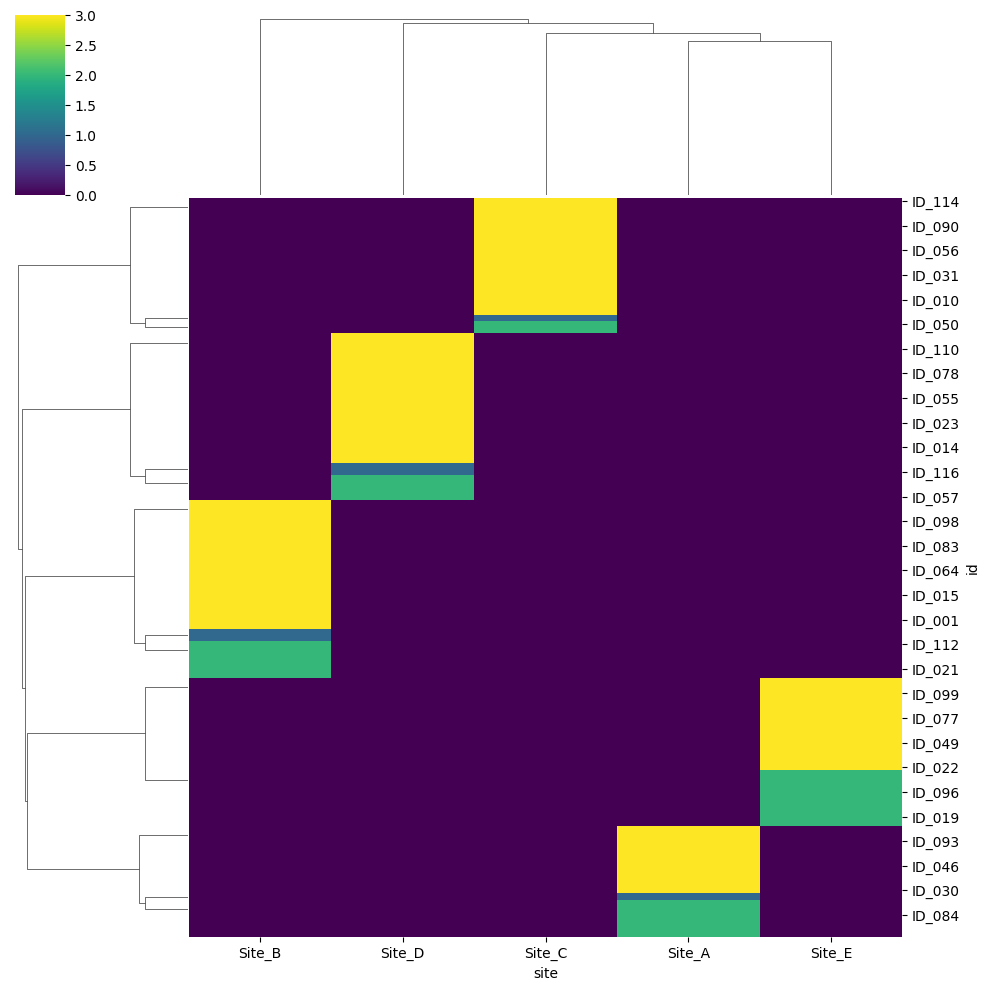

In [16]:
df_to_plot = pd.crosstab(data['id'], data['site'])
sns.clustermap(df_to_plot, cmap='viridis', vmin=0, vmax=3)

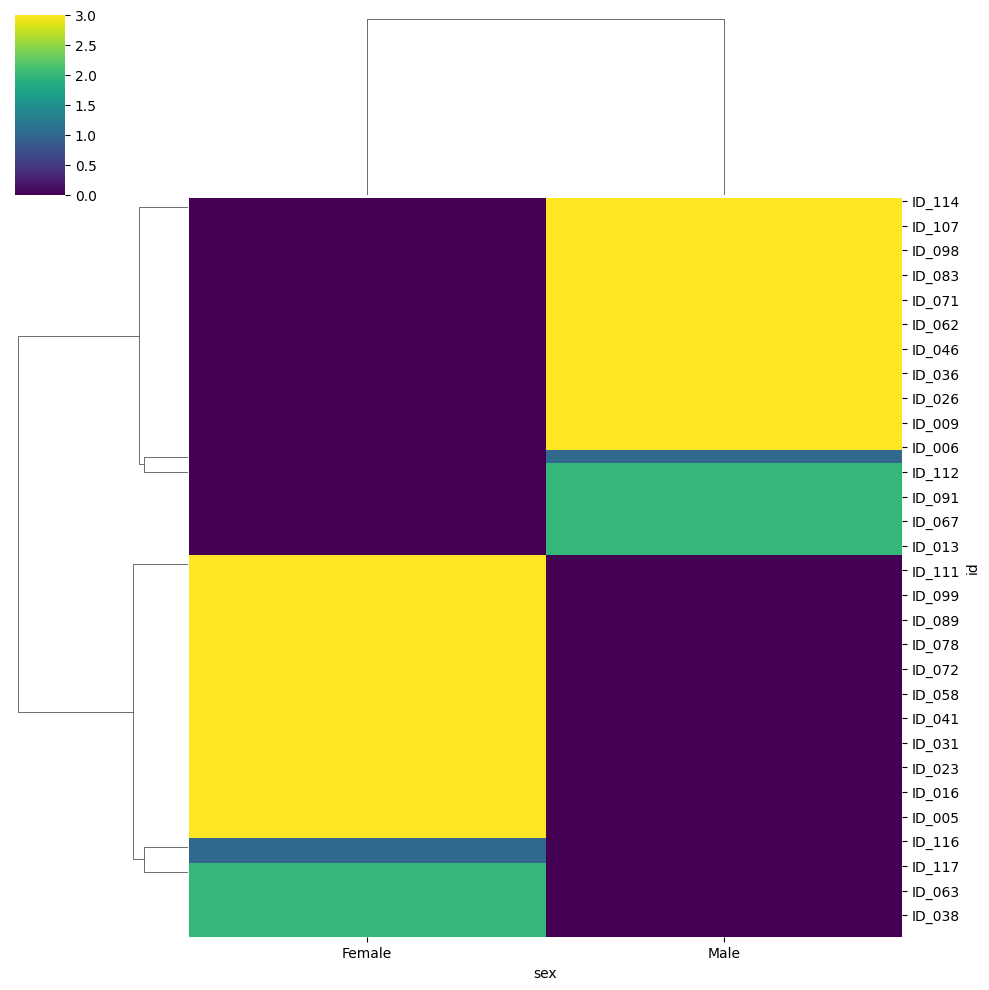

In [18]:
df_to_plot = pd.crosstab(data['id'], data['sex'])
sns.clustermap(df_to_plot, cmap='viridis', vmin=0, vmax=3)

ValueError: could not convert string to float: 'Site_C'

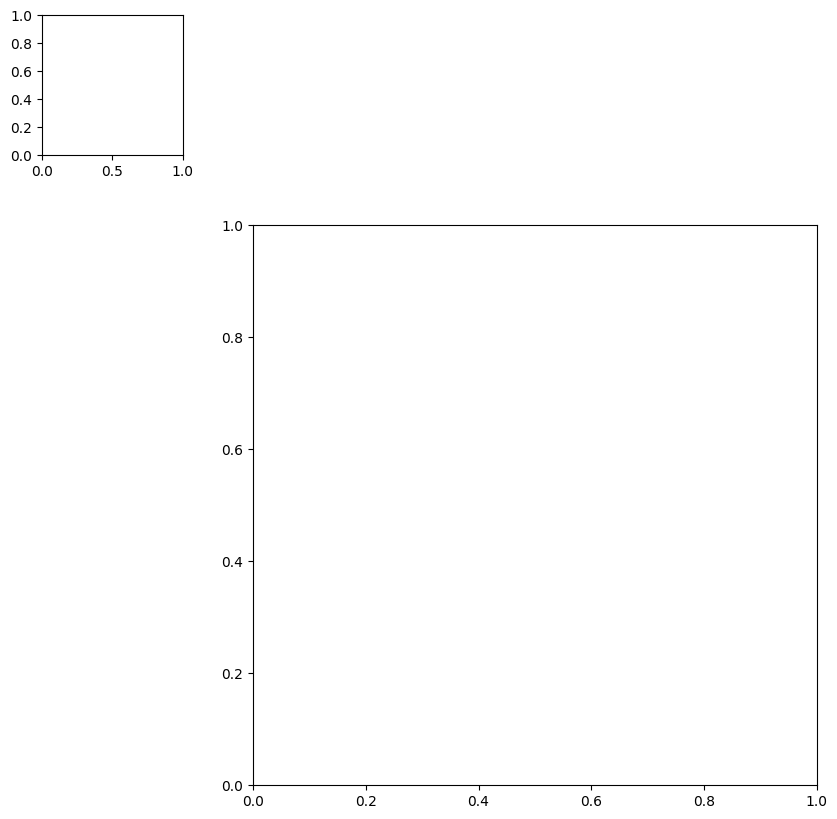

In [22]:
df_to_plot = data.drop_duplicates(subset=['id', 'site', 'sex', 'age'], keep='first')
sns.clustermap(df_to_plot[['site', 'sex']], cmap='viridis')

<Axes: xlabel='time', ylabel='biomarker'>

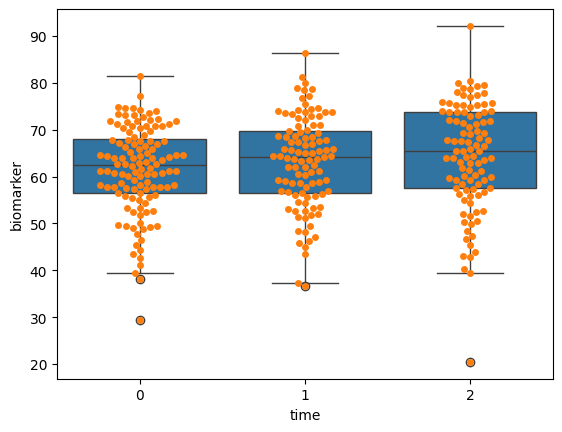

In [7]:
sns.boxplot(x='time', y='biomarker', data=data)
sns.swarmplot(x='time', y='biomarker', data=data)

<Axes: xlabel='time', ylabel='biomarker'>

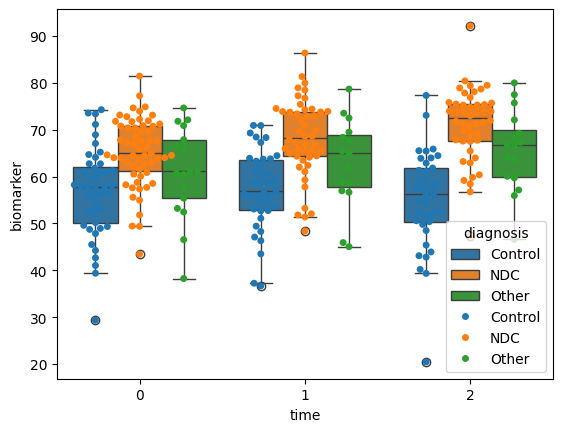

In [ ]:
sns.boxplot(x='time', y='biomarker', data=data, hue='diagnosis', hue_order=['Control', 'NDC', 'Other'])
sns.swarmplot(x='time', y='biomarker', data=data, hue='diagnosis', hue_order=['Control', 'NDC', 'Other'], dodge=True, legends=False)

## ANOVA

In [25]:
model = ols('biomarker ~ time * C(diagnosis)', data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              biomarker   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     26.86
Date:                Sat, 30 May 2026   Prob (F-statistic):           1.30e-22
Time:                        18:47:24   Log-Likelihood:                -1144.5
No. Observations:                 321   AIC:                             2301.
Df Residuals:                     315   BIC:                             2324.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [26]:
model = glm('biomarker ~ time * C(diagnosis)', data=data).fit()
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              biomarker   No. Observations:                  321
Model:                            GLM   Df Residuals:                      315
Model Family:                Gaussian   Df Model:                            5
Link Function:               Identity   Scale:                          74.597
Method:                          IRLS   Log-Likelihood:                -1144.5
Date:                Sat, 30 May 2026   Deviance:                       23498.
Time:                        18:48:38   Pearson chi2:                 2.35e+04
No. Iterations:                     3   Pseudo R-squ. (CS):             0.3420
Covariance Type:            nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [14]:
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                      sum_sq     df          F        PR(>F)
diagnosis        8955.704564    2.0  60.027323  8.189587e-23
time              481.889694    1.0   6.459916  1.151248e-02
time:diagnosis    637.064782    2.0   4.270049  1.479908e-02
Residual        23498.023837  315.0        NaN           NaN


## ANCOVA

Add age, sex, and, site as covariates

In [22]:
# age only
model = ols('biomarker ~ time * C(diagnosis) + age', data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              biomarker   R-squared:                       0.326
Model:                            OLS   Adj. R-squared:                  0.313
Method:                 Least Squares   F-statistic:                     25.31
Date:                Sat, 30 May 2026   Prob (F-statistic):           1.75e-24
Time:                        16:43:44   Log-Likelihood:                -1138.2
No. Observations:                 321   AIC:                             2290.
Df Residuals:                     314   BIC:                             2317.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [23]:
# sex only
model = ols('biomarker ~ time * C(diagnosis) + C(sex)', data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              biomarker   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.330
Method:                 Least Squares   F-statistic:                     27.30
Date:                Sat, 30 May 2026   Prob (F-statistic):           3.57e-26
Time:                        16:44:05   Log-Likelihood:                -1134.1
No. Observations:                 321   AIC:                             2282.
Df Residuals:                     314   BIC:                             2309.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [24]:
# site only
model = ols('biomarker ~ time * C(diagnosis) + C(site)', data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              biomarker   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.386
Method:                 Least Squares   F-statistic:                     23.36
Date:                Sat, 30 May 2026   Prob (F-statistic):           2.44e-30
Time:                        16:44:24   Log-Likelihood:                -1118.7
No. Observations:                 321   AIC:                             2257.
Df Residuals:                     311   BIC:                             2295.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [18]:
model = ols('biomarker ~ time * C(diagnosis) + age + C(sex)', data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              biomarker   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     27.20
Date:                Sat, 30 May 2026   Prob (F-statistic):           4.35e-29
Time:                        16:36:36   Log-Likelihood:                -1125.3
No. Observations:                 321   AIC:                             2267.
Df Residuals:                     313   BIC:                             2297.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [17]:
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                      sum_sq     df          F        PR(>F)
diagnosis        8975.231226    2.0  67.401797  4.544470e-25
sex              1751.458036    1.0  26.306045  5.117994e-07
time              504.578329    1.0   7.578520  6.251645e-03
time:diagnosis    672.331642    2.0   5.049047  6.947939e-03
age              1184.673269    1.0  17.793215  3.228434e-05
Residual        20839.558316  313.0        NaN           NaN


## Mixed Model

In [32]:
model = mixedlm('biomarker ~ time * C(diagnosis) + age + C(sex) + C(site)', data=data, groups=data['id']).fit(reml=False)
print(model.summary())

                Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     biomarker 
No. Observations:      321         Method:                 ML        
No. Groups:            120         Scale:                  15.3618   
Min. group size:       1           Log-Likelihood:         -1015.8237
Max. group size:       3           Converged:              Yes       
Mean group size:       2.7                                           
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  40.091    3.236 12.391 0.000 33.749 46.433
C(diagnosis)[T.NDC]         8.786    1.444  6.083 0.000  5.955 11.616
C(diagnosis)[T.Other]       4.167    2.118  1.968 0.049  0.017  8.318
C(sex)[T.Male]              4.768    1.255  3.799 0.000  2.308  7.228
C(site)[T.Site_B]           5.284   

In [29]:
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

ValueError: shapes (4,12) and (13,13) not aligned: 12 (dim 1) != 13 (dim 0)

In [31]:
# biomarker ~ diagnosis * time + age + sex + medication + (1 | site/id)
    # id is nested within site, so we need to specify random intercepts for both site and id


model = mixedlm(
    "biomarker ~ diagnosis * time + age + sex + medication",
    data=data,
    groups="site",                 # random intercept for site
    re_formula="1",
    vc_formula={
        "id": "0 + C(id)"           # random intercept for subjects within site
    },
)

result = model.fit(reml=False)
print(result.summary())

              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    biomarker 
No. Observations:     321        Method:                ML        
No. Groups:           5          Scale:                 15.3542   
Min. group size:      46         Log-Likelihood:        -1020.2121
Max. group size:      77         Converged:             Yes       
Mean group size:      64.2                                        
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept               45.822    3.295 13.906 0.000 39.364 52.281
diagnosis[T.NDC]         7.750    1.485  5.220 0.000  4.840 10.660
diagnosis[T.Other]       3.919    2.103  1.864 0.062 -0.202  8.041
sex[T.Male]              4.504    1.248  3.608 0.000  2.058  6.951
medication[T.Yes]        3.368    1.306  2.578 0.010  0.807  5.928
time      